In [73]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
file_path = "../data/processed/unsw_nb15_processed.csv"

df = pd.read_csv(file_path)

print("Dataset loaded")
print(df.shape)

Dataset loaded
(162122, 45)


In [75]:
X = df.drop(["id","label", "attack_cat"], axis=1)
y = df["label"]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (162122, 42)
Label shape: (162122,)


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 129697
Testing samples: 32425


In [77]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model training complete")

Model training complete


In [78]:
y.value_counts()

label
1    106122
0     56000
Name: count, dtype: int64

In [79]:
importances = rf_model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(20)

print(top_features)

sttl              0.162758
ct_state_ttl      0.124793
dload             0.062504
dttl              0.054977
rate              0.054081
ackdat            0.046489
sload             0.041542
dmean             0.033683
tcprtt            0.031972
sbytes            0.029270
ct_srv_dst        0.026586
dbytes            0.025919
dur               0.025278
smean             0.025112
synack            0.023425
dinpkt            0.022853
dpkts             0.021886
ct_dst_src_ltm    0.021001
sinpkt            0.019882
ct_srv_src        0.019624
dtype: float64


In [80]:
y_pred = rf_model.predict(X_test)

In [81]:
print("Classification Report:")

print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     11114
           1       0.96      0.98      0.97     21311

    accuracy                           0.96     32425
   macro avg       0.96      0.95      0.95     32425
weighted avg       0.96      0.96      0.96     32425



In [82]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr = fp / (fp + tn)

print("False Positive Rate:", f"{fpr:.4%}")

False Positive Rate: 8.7727%


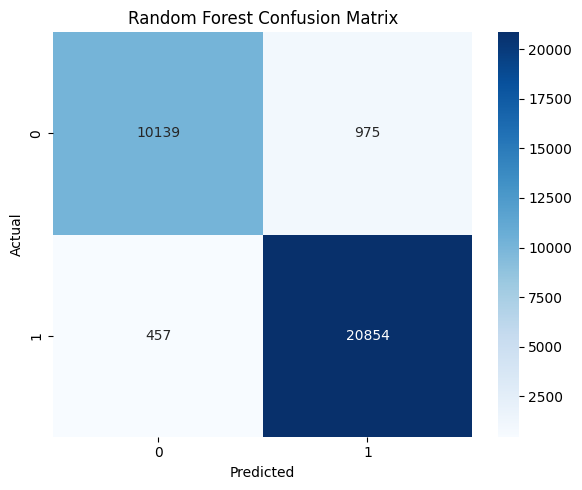

In [83]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_rf.png", dpi=300)
plt.show()

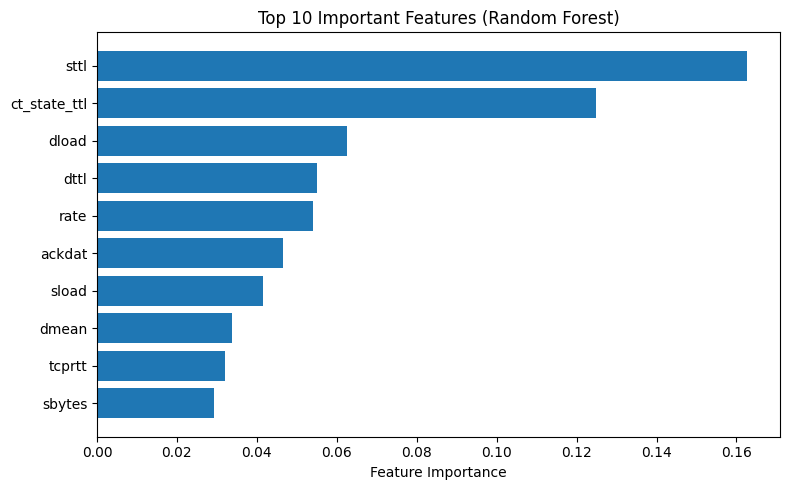

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/feature_importance_rf.png", dpi=300)
plt.show()

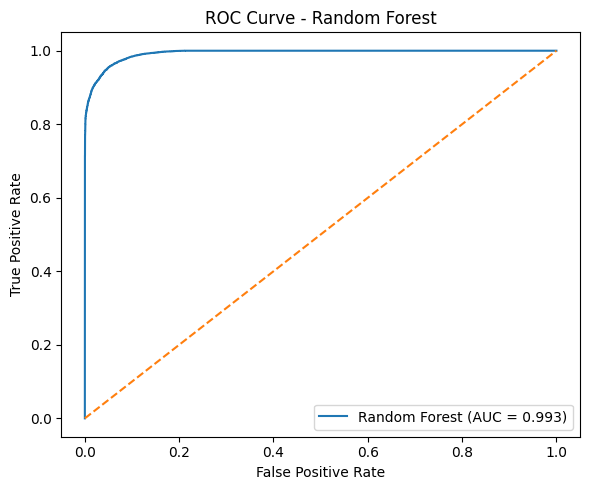

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob)
rf_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/roc_curve_random_forest.png", dpi=300)
plt.show()

In [86]:
import joblib

joblib.dump(rf_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']